In [1]:
!nvidia-smi

Mon Jan  5 13:38:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1660 Ti     Off |   00000000:01:00.0 Off |                  N/A |
| N/A   40C    P8              3W /   15W |       7MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch

tensor = torch.tensor([1.0, 2.0, 3.0])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# We move our tensor to the GPU if available
if torch.cuda.is_available():
  tensor = tensor.to('cuda')
  print(f"Device tensor is stored on: {tensor.device}")

Device tensor is stored on: cuda:0


In [13]:
import torch
import torchvision

print("modules loaded")

modules loaded


In [20]:
from transforms import train_transform, test_transform

weather_images = torchvision.datasets.ImageFolder(root='dataset')

# 3. Split the raw data
train_raw, test_raw, val_raw = torch.utils.data.random_split(weather_images, [0.6, 0.2, 0.2])

# 4. WRAP them in a class or apply transform manually
# In PyTorch, random_split returns a Subset. To give them different transforms:
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)

# Dotychczasowy błąd polegał na tym, że trainset i valset używały tych samych transformacji.
# Nie powinny, ponieważ augmentacje powinny być stosowane tylko do zbioru treningowego.
# dlaczego? Bo augmentacje mają na celu zwiększenie różnorodności danych treningowych, co pomaga modelowi
# uczyć się bardziej ogólnych cech i unikać przeuczenia. Zbiór walidacyjny i testowy powinny odzwierciedlać rzeczywiste dane,
# na których model będzie działał, więc nie powinny zawierać sztucznych zmian.
trainset = ApplyTransform(train_raw, transform=train_transform)
testset = ApplyTransform(test_raw, transform=test_transform)
valset = ApplyTransform(val_raw, transform=test_transform)

batch_size = 32

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)


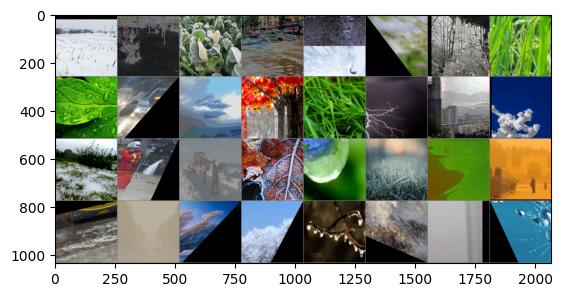

snow  snow  frost rain  glaze rain  glaze dew   dew   rain  sandstorm snow  dew   lightning fogsmog rime  hail  rain  snow  frost glaze frost sandstorm sandstorm rain  sandstorm rime  rime  glaze rime  fogsmog dew  


torch.Size([3, 256, 256])

In [21]:
# sposób wyświetlenia obrazków i labelek

import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{trainloader.dataset.subset.dataset.classes[labels[j]]:5s}' for j in range(batch_size)))

images[0].shape

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch

import torch

from model import ResNet

net = ResNet(3, trainloader.dataset.subset.dataset.classes.__len__())
net.to(device)
net = torch.compile(net)
print(net)

OptimizedModule(
  (_orig_mod): ResNet(
    (conv1): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (drop): Dropout(p=0.5, inplace=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (res_layer_1): Sequential(
      (0): ResidualBlock(
        (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (shortcut): Sequential(
          (0): Conv2d(128, 256, kernel_size=(1, 1), stride=(2, 2), bias=False)
          (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (1): ResidualBlock(
        (conv1): Conv2d(256, 256, kernel_

In [18]:
torch.cuda.empty_cache()

In [21]:
from tqdm import trange
# Updated tracking structures

# - Zero (the gradients)

# - Forward (get predictions)

# - Loss (calculate error)

# - Backward (calculate gradients)

# - Step (update weights)

torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')

print("START TRAINING")
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
EPOCHS = 100
import torch.optim as optim

lr = 1e-3
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(net.parameters(), lr=lr, betas=(0.9, 0.999), weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6)
best_val_loss = float('inf')

for epoch in (pbar := trange(1, EPOCHS+1)):
    net.train()
    running_train_loss = 0.0
    
    for i, (inputs, labels) in enumerate(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad(set_to_none=True)
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        pbar.set_description(f"epoch: {epoch}, iter: {i}/{len(trainloader)}, train_loss: {loss.item()}")

    # Calculate average epoch loss
    epoch_train_loss = running_train_loss / len(trainloader)
    
    # Validation Phase
    net.eval()
    running_val_loss = 0.0
    correct = 0
    
    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            running_val_loss += criterion(outputs, labels).item()
            
            pred = outputs.argmax(dim=1)
            correct += (pred == labels).sum().item()

    epoch_val_loss = running_val_loss / len(valloader)
    epoch_val_acc = correct / len(valloader.dataset)

    scheduler.step(epoch_val_loss)

    # Store metrics once per epoch for clean plotting
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(net.state_dict(), 'best_model.pth')
    
    # torch.save(net.state_dict(), 'checkpoints/resnet_epoch_{}.pth'.format(epoch+1))

    # early stopping if Val Loss does not improve for 5 consecutive epochs
    # if epoch > 5:
    #     if all(history['val_loss'][-1] >= history['val_loss'][-i] for i in range(2, 2 + 5)):
    #         print("Early stopping triggered")
    #         break

    print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

torch.save(net.state_dict(), 'weather_resnet.pth')

START TRAINING


epoch: 1, iter: 128/129, train_loss: 0.5416191220283508:   2%|▏         | 1/50 [01:21<1:06:56, 81.97s/it]

Epoch 2 | Train Loss: 0.8137 | Val Loss: 0.4907


epoch: 2, iter: 128/129, train_loss: 0.8959394097328186:   4%|▍         | 2/50 [02:44<1:05:45, 82.19s/it]

Epoch 3 | Train Loss: 0.8356 | Val Loss: 0.5181


...

Epoch 49 | Train Loss: 0.5989 | Val Loss: 0.3589


epoch: 49, iter: 128/129, train_loss: 0.39584705233573914:  98%|█████████▊| 49/50 [1:07:22<01:22, 82.52s/it]

Epoch 50 | Train Loss: 0.5991 | Val Loss: 0.3678


epoch: 50, iter: 128/129, train_loss: 0.4708231985569: 100%|██████████| 50/50 [1:08:44<00:00, 82.50s/it]    

Epoch 51 | Train Loss: 0.5725 | Val Loss: 0.3490


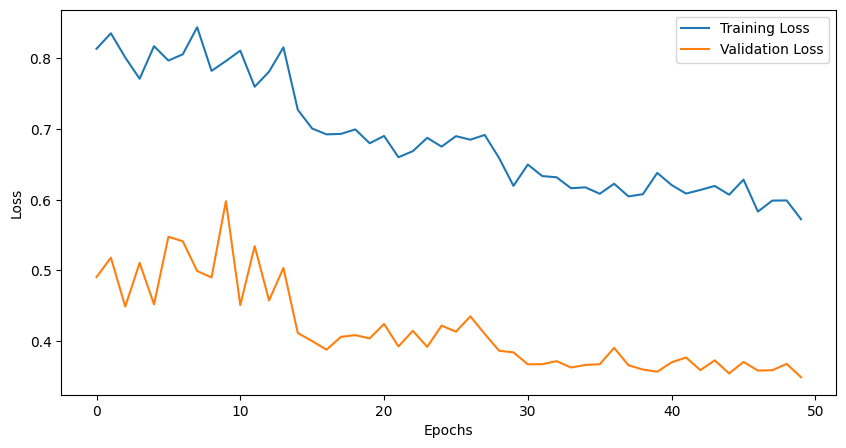

In [22]:
plt.figure(figsize=(10,5))
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [23]:
params = list(net.parameters())
print(len(params))
print(params[0].size())  # conv1's .weight

35
torch.Size([128, 3, 3, 3])


In [11]:
# Wyznaczanie całkowitej jakości klasyfikacji sieci na zbiorze testowym
classes = trainloader.dataset.subset.dataset.classes
print(classes.__len__())
net = ResNet(3, len(classes))
net.to(device)
net = torch.compile(net)
net.load_state_dict(torch.load('best.pth'))
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images.to(device))
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels.to(device)).sum().item()
        break
print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

11
Accuracy of the network on the 10000 test images: 93 %


In [ ]:
# Wyznaczanie jakości klasyfikacji dla poszczególnych klas

# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}
total = 0
correct = 0

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images.to('cuda'))
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels.to('cuda'), predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels.to(device)).sum().item()
        break


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')
print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')


Accuracy for class: dew   is 88.2 %
Accuracy for class: fogsmog is 88.6 %
Accuracy for class: frost is 69.7 %
Accuracy for class: glaze is 79.5 %
Accuracy for class: hail  is 90.7 %
Accuracy for class: lightning is 100.0 %
Accuracy for class: rain  is 71.4 %
Accuracy for class: rainbow is 95.3 %
Accuracy for class: rime  is 84.3 %
Accuracy for class: sandstorm is 91.8 %
Accuracy for class: snow  is 68.0 %


rime  rime  frost fogsmog frost lightning rime  snow  rain  sandstorm sandstorm lightning rime  rime  fogsmog rainbow fogsmog rime  rain  rain  glaze glaze frost dew   snow  fogsmog hail  hail  fogsmog fogsmog rime  glaze


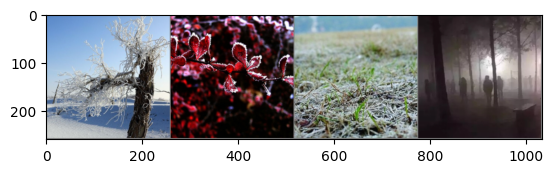

Predicted: rime, Actual: rime
Predicted: dew, Actual: rime
Predicted: glaze, Actual: frost
Predicted: fogsmog, Actual: fogsmog


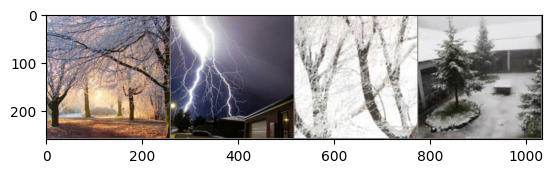

Predicted: rime, Actual: frost
Predicted: lightning, Actual: lightning
Predicted: rime, Actual: rime
Predicted: snow, Actual: snow


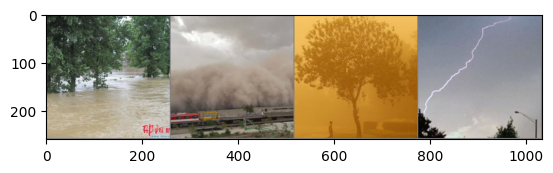

Predicted: rain, Actual: rain
Predicted: sandstorm, Actual: sandstorm
Predicted: sandstorm, Actual: sandstorm
Predicted: lightning, Actual: lightning


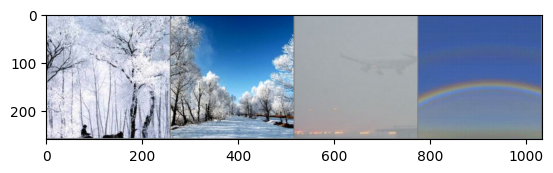

Predicted: glaze, Actual: rime
Predicted: rime, Actual: rime
Predicted: fogsmog, Actual: fogsmog
Predicted: rainbow, Actual: rainbow


In [26]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()
# get some random training images
dataiter = iter(testloader)
images, labels = next(dataiter)

outputs = net(images.to('cuda'))
_, predicted = torch.max(outputs, 1)

# show images
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

images[0].shape

# display 4 at time
for i in range(4):
    imshow(torchvision.utils.make_grid(images[i*4:4+i*4].cpu()))
    for j in range(4):
        print(f'Predicted: {classes[predicted[i*4+j]]}, Actual: {classes[labels[i*4+j]]}')